# Walmart M5 Dynamic Pricing

## Business Objective

Notebook 05 accepted the development demand-forecasting model and documented its remaining limitations.

This notebook adds the **dynamic-pricing simulation layer**.

The goal is to answer:

> Given a current price, a baseline demand forecast, and an explicit price-response assumption, which allowed price produces the highest expected revenue?

This notebook deliberately separates two ideas:

1. **Demand forecasting**  
   Predict expected demand under normal/current conditions.

2. **Price-response modeling**  
   Estimate how demand may change if price changes.

A demand forecast by itself does **not** prove causal price elasticity. Therefore this notebook uses a transparent, scenario-based pricing framework rather than assuming the forecasting model learned a causal price effect.

The notebook will:

- explore historical within-item price changes
- estimate conservative item-level elasticity assumptions
- label elasticity estimates as observed or fallback
- generate candidate prices around the current price
- estimate scenario demand under each candidate
- estimate expected revenue
- use tie-handling so economically equivalent prices stay close to the current price
- enforce pricing guardrails
- identify actionable recommendations
- save pricing outputs for the future API and dashboard

> **Important:** All revenue-lift results in this notebook are simulated under stated elasticity assumptions. They are not evidence that real-world revenue will increase by the same amount.

## 1. Import Libraries

In [1]:
from pathlib import Path
import json
import warnings

import joblib
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd

warnings.filterwarnings("ignore")

## 2. Define Project Paths

Notebook 04 saved the trained forecasting pipeline and model metadata.

Notebook 05 saved evaluation outputs.

Notebook 03 saved the feature-engineered dataset used for modeling.

In [2]:
PROJECT_ROOT = Path("..")

PROCESSED_DIR = PROJECT_ROOT / "data" / "processed"
MODEL_DIR = PROJECT_ROOT / "models"
MODELING_OUTPUT_DIR = PROJECT_ROOT / "outputs" / "modeling"
PRICING_OUTPUT_DIR = PROJECT_ROOT / "outputs" / "pricing"

FEATURE_FILE = (
    PROCESSED_DIR
    / "features_CA_1_200_items.csv"
)

MODEL_FILE = (
    MODEL_DIR
    / "demand_forecast_model.joblib"
)

METADATA_FILE = (
    MODEL_DIR
    / "demand_forecast_model_metadata.json"
)

TEST_PREDICTIONS_FILE = (
    MODELING_OUTPUT_DIR
    / "test_predictions.csv"
)

PRICING_OUTPUT_DIR.mkdir(
    parents=True,
    exist_ok=True,
)

PRICING_RECOMMENDATIONS_FILE = (
    PRICING_OUTPUT_DIR
    / "pricing_recommendations.csv"
)

## 3. Load Modeling and Pricing Inputs

In [3]:
features = pd.read_csv(
    FEATURE_FILE,
    parse_dates=["date"],
)

test_predictions = pd.read_csv(
    TEST_PREDICTIONS_FILE,
    parse_dates=["date"],
)

forecast_pipeline = joblib.load(
    MODEL_FILE
)

with open(
    METADATA_FILE,
    "r",
    encoding="utf-8",
) as file:
    metadata = json.load(file)

print("Feature data:", features.shape)
print("Test predictions:", test_predictions.shape)
print("Forecast model:", metadata["selected_model"])

Feature data: (382600, 47)
Test predictions: (5600, 7)
Forecast model: poisson_hist_gradient_boosting


## 4. Pricing Scope and Assumptions

This notebook is a **development pricing simulation**, not a causal production pricing system.

Important assumptions:

- the Notebook 04 model provides the baseline demand forecast
- price changes affect demand through a separate elasticity assumption
- candidate prices stay within a limited range around the current price
- recommended prices cannot be negative
- products without a valid current price are excluded
- profitability is not optimized yet because product-level cost data is not available

Therefore the optimization target is **expected revenue**, not profit.

Revenue:

`price × expected demand`

## 5. Historical Price-Response Exploration

Notebook 02 showed that aggregate price and demand had a positive raw correlation, which was **not causal**.

For pricing, we instead look within each item and study how weekly demand changes when the item's price changes.

Even this remains observational data, so the resulting elasticity is treated as a development assumption rather than a causal estimate.

In [4]:
pricing_history = features[
    [
        "date",
        "item_id",
        "store_id",
        "units_sold",
        "sell_price",
    ]
].copy()

pricing_history = pricing_history.loc[
    pricing_history["sell_price"].notna()
    & (pricing_history["sell_price"] > 0)
].copy()

pricing_history["week_start"] = (
    pricing_history["date"]
    - pd.to_timedelta(
        pricing_history["date"].dt.dayofweek,
        unit="D",
    )
)

weekly_item = (
    pricing_history
    .groupby(
        [
            "item_id",
            "store_id",
            "week_start",
        ],
        as_index=False,
    )
    .agg(
        weekly_units=("units_sold", "sum"),
        weekly_price=("sell_price", "mean"),
    )
)

weekly_item.head()

,item_id,store_id,week_start,weekly_units,weekly_price
0,FOODS_1_001,CA_1,2011-02-21,4,2.0
1,FOODS_1_001,CA_1,2011-02-28,16,2.0
2,FOODS_1_001,CA_1,2011-03-07,12,2.0
3,FOODS_1_001,CA_1,2011-03-14,3,2.0
4,FOODS_1_001,CA_1,2011-03-21,8,2.0


## 6. Estimate Development Price Elasticity

For each item-store series, compare percentage price change with percentage demand change between consecutive weeks.

Elasticity approximation:

`% change in demand / % change in price`

We keep only observations where price actually changed.

Extreme elasticity values are clipped because observational retail data can contain promotions, availability changes, seasonality, and noise.

In [5]:
weekly_item = weekly_item.sort_values(
    [
        "item_id",
        "store_id",
        "week_start",
    ]
).copy()

weekly_item["previous_price"] = (
    weekly_item
    .groupby(
        [
            "item_id",
            "store_id",
        ]
    )["weekly_price"]
    .shift(1)
)

weekly_item["previous_units"] = (
    weekly_item
    .groupby(
        [
            "item_id",
            "store_id",
        ]
    )["weekly_units"]
    .shift(1)
)

weekly_item["price_change_pct"] = (
    weekly_item["weekly_price"]
    / weekly_item["previous_price"]
    - 1
)

weekly_item["demand_change_pct"] = (
    weekly_item["weekly_units"]
    / weekly_item["previous_units"].replace(0, np.nan)
    - 1
)

elasticity_observations = weekly_item.loc[
    weekly_item["price_change_pct"].abs() >= 0.01
].copy()

elasticity_observations["elasticity"] = (
    elasticity_observations["demand_change_pct"]
    / elasticity_observations["price_change_pct"]
)

elasticity_observations = elasticity_observations.loc[
    elasticity_observations["elasticity"]
    .replace([np.inf, -np.inf], np.nan)
    .notna()
].copy()

elasticity_observations["elasticity"] = (
    elasticity_observations["elasticity"]
    .clip(-5, 2)
)

elasticity_observations[
    "elasticity"
].describe()

count    563.000000
mean      -1.336846
std        3.227878
min       -5.000000
25%       -5.000000
50%        0.000000
75%        2.000000
max        2.000000
Name: elasticity, dtype: float64

## 7. Build Item-Level Elasticity Assumptions

Economic demand elasticity is generally expected to be negative: higher price tends to reduce demand.

The historical estimates are noisy, so the notebook uses an observed elasticity only when:

- the item-store series has at least the minimum number of usable price-change observations
- the median historical elasticity is negative

Otherwise the pricing engine uses a conservative fallback elasticity of `-1.0`.

Observed elasticities are constrained to:

`-3.0 to -0.2`

This avoids implausibly extreme responses.

The same validity rule also determines the `elasticity_source` label so an item cannot be marked **Observed** while actually using the fallback assumption.

In [6]:
MIN_ELASTICITY_OBSERVATIONS = 3
FALLBACK_ELASTICITY = -1.0

item_elasticity = (
    elasticity_observations
    .groupby(
        [
            "item_id",
            "store_id",
        ],
        as_index=False,
    )
    .agg(
        estimated_elasticity=("elasticity", "median"),
        elasticity_observations=("elasticity", "count"),
    )
)

# One consistent rule determines both:
# 1. whether the observed estimate is trusted
# 2. whether the row is labeled Observed or Fallback
valid_observed_elasticity = (
    (
        item_elasticity["elasticity_observations"]
        >= MIN_ELASTICITY_OBSERVATIONS
    )
    & (
        item_elasticity["estimated_elasticity"] < 0
    )
)

item_elasticity["elasticity_source"] = np.where(
    valid_observed_elasticity,
    "Observed",
    "Fallback",
)

item_elasticity["usable_elasticity"] = np.where(
    valid_observed_elasticity,
    item_elasticity["estimated_elasticity"],
    FALLBACK_ELASTICITY,
)

item_elasticity["usable_elasticity"] = (
    item_elasticity["usable_elasticity"]
    .clip(-3.0, -0.2)
)

item_elasticity.head()

,item_id,store_id,estimated_elasticity,elasticity_observations,elasticity_source,usable_elasticity
0,FOODS_1_001,CA_1,-1.500000,2,Fallback,-1.0
1,FOODS_1_002,CA_1,-1.500000,4,Observed,-1.5
2,FOODS_1_003,CA_1,-1.500000,2,Fallback,-1.0
3,FOODS_1_004,CA_1,-4.522727,6,Observed,-3.0
4,FOODS_1_006,CA_1,-4.016402,4,Observed,-3.0


## 8. Create Pricing Evaluation Base

Join the final test predictions to current price information and the item-level price-response assumptions.

Each pricing-eligible row contains:

- actual demand
- baseline predicted demand
- current price
- usable elasticity
- elasticity evidence count
- elasticity source (`Observed` or `Fallback`)

Products without a valid positive current price are excluded from pricing simulation.

In [7]:
pricing_base = test_predictions.merge(
    features[
        [
            "date",
            "item_id",
            "store_id",
            "sell_price",
            "price_available",
        ]
    ],
    on=[
        "date",
        "item_id",
        "store_id",
    ],
    how="left",
    validate="one_to_one",
)

pricing_base = pricing_base.merge(
    item_elasticity[
        [
            "item_id",
            "store_id",
            "usable_elasticity",
            "elasticity_observations",
            "elasticity_source",
        ]
    ],
    on=[
        "item_id",
        "store_id",
    ],
    how="left",
    validate="many_to_one",
)

# Items without a usable observed estimate use the fallback assumption.
pricing_base["usable_elasticity"] = (
    pricing_base["usable_elasticity"]
    .fillna(FALLBACK_ELASTICITY)
)

pricing_base["elasticity_observations"] = (
    pricing_base["elasticity_observations"]
    .fillna(0)
)

pricing_base["elasticity_source"] = (
    pricing_base["elasticity_source"]
    .fillna("Fallback")
)

pricing_base = pricing_base.loc[
    pricing_base["sell_price"].notna()
    & (pricing_base["sell_price"] > 0)
].copy()

print(
    "Pricing-eligible rows:",
    f"{len(pricing_base):,}",
)

pricing_base.head()

Pricing-eligible rows: 5,600


,date,item_id,store_id,units_sold,prediction,residual,absolute_error,sell_price,price_available,usable_elasticity,elasticity_observations,elasticity_source
0,2016-04-25,FOODS_1_001,CA_1,2,0.811261,1.188739,1.188739,2.24,1,-1.0,2.0,Fallback
1,2016-04-25,FOODS_1_002,CA_1,0,0.450272,-0.450272,0.450272,9.48,1,-1.5,4.0,Observed
2,2016-04-25,FOODS_1_003,CA_1,3,0.702118,2.297882,2.297882,3.23,1,-1.0,2.0,Fallback
3,2016-04-25,FOODS_1_004,CA_1,0,0.056105,-0.056105,0.056105,1.96,1,-3.0,6.0,Observed
4,2016-04-25,FOODS_1_005,CA_1,1,1.291144,-0.291144,0.291144,3.54,1,-1.0,0.0,Fallback


## 9. Define Candidate Price Guardrails

To avoid unrealistic recommendations, candidate prices are limited to:

- maximum **10% decrease**
- maximum **10% increase**
- 2.5% steps

These constraints can later become configurable business rules in the API.

In [8]:
PRICE_CHANGE_OPTIONS = np.array([
    -0.10,
    -0.075,
    -0.05,
    -0.025,
    0.00,
    0.025,
    0.05,
    0.075,
    0.10,
])

PRICE_FLOOR = 0.01

## 10. Price-Response Function

A constant-elasticity demand curve is used for scenario analysis:

`scenario demand = baseline demand × (new price / current price) ^ elasticity`

For example, with elasticity `-1.0`, a proportional increase in price is offset by an inverse change in expected demand, which can make expected revenue almost unchanged across several candidate prices.

This is why the recommendation logic later includes a **revenue tolerance**: if multiple prices are economically equivalent, the engine prefers the price closest to the current price instead of making an unnecessary change.

This framework is transparent and can later be replaced with a stronger causal price-response model.

In [9]:
def estimate_scenario_demand(
    baseline_demand,
    current_price,
    candidate_price,
    elasticity,
):
    if (
        baseline_demand < 0
        or current_price <= 0
        or candidate_price <= 0
    ):
        return np.nan

    relative_price = (
        candidate_price
        / current_price
    )

    scenario_demand = (
        baseline_demand
        * relative_price ** elasticity
    )

    return max(
        scenario_demand,
        0,
    )

## 11. Generate Candidate Prices for One Example

Inspect the pricing mechanics on one test observation before scaling the logic.

In [10]:
example_row = pricing_base.iloc[0]

example_candidates = []

for change_pct in PRICE_CHANGE_OPTIONS:

    current_price = (
        example_row["sell_price"]
    )

    candidate_price = max(
        current_price
        * (1 + change_pct),
        PRICE_FLOOR,
    )

    expected_demand = (
        estimate_scenario_demand(
            baseline_demand=example_row["prediction"],
            current_price=current_price,
            candidate_price=candidate_price,
            elasticity=example_row["usable_elasticity"],
        )
    )

    expected_revenue = (
        candidate_price
        * expected_demand
    )

    example_candidates.append({
        "price_change_pct": change_pct,
        "candidate_price": candidate_price,
        "expected_demand": expected_demand,
        "expected_revenue": expected_revenue,
    })

example_candidates_df = pd.DataFrame(
    example_candidates
)

example_candidates_df

,price_change_pct,candidate_price,expected_demand,expected_revenue
0,-0.100,2.016,0.901401,1.817224
1,-0.075,2.072,0.877039,1.817224
2,-0.050,2.128,0.853959,1.817224
3,-0.025,2.184,0.832062,1.817224
4,0.000,2.240,0.811261,1.817224
5,0.025,2.296,0.791474,1.817224
6,0.050,2.352,0.772629,1.817224
7,0.075,2.408,0.754661,1.817224
8,0.100,2.464,0.737510,1.817224


## 12. Visualize the Example Price-Revenue Curve

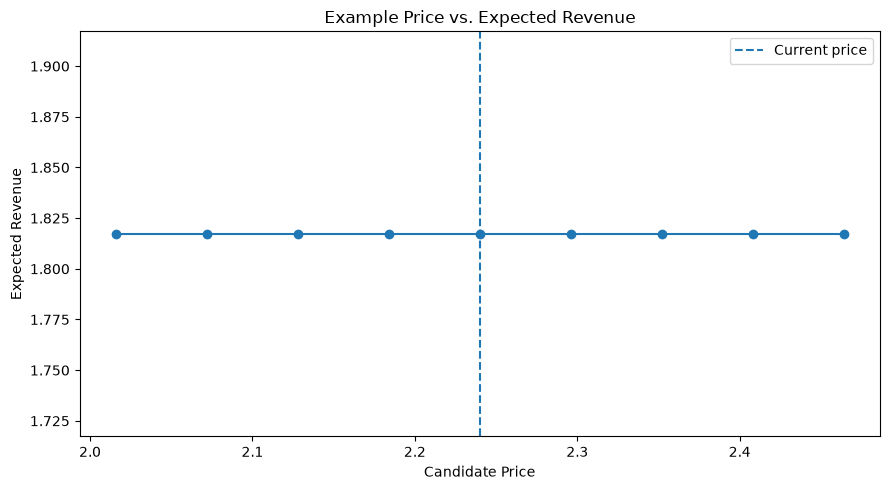

In [11]:
fig, ax = plt.subplots(figsize=(9, 5))

ax.plot(
    example_candidates_df[
        "candidate_price"
    ],
    example_candidates_df[
        "expected_revenue"
    ],
    marker="o",
)

ax.axvline(
    example_row["sell_price"],
    linestyle="--",
    label="Current price",
)

ax.set_title(
    "Example Price vs. Expected Revenue"
)
ax.set_xlabel("Candidate Price")
ax.set_ylabel("Expected Revenue")
ax.legend()

plt.tight_layout()
plt.show()

## 13. Pricing Recommendation Function

For each pricing-eligible row:

1. generate allowed candidate prices
2. estimate scenario demand
3. estimate scenario revenue
4. find the maximum expected revenue
5. treat prices within a small revenue tolerance as economically equivalent
6. among near-equal candidates, choose the price closest to the current price

The final tie rule prevents floating-point noise from creating unnecessary price changes when expected revenues are effectively identical.

In [12]:
REVENUE_TOLERANCE_PCT = 0.001

def recommend_price_for_row(
    row,
):
    current_price = row["sell_price"]
    baseline_demand = row["prediction"]
    elasticity = row["usable_elasticity"]

    scenarios = []

    for change_pct in PRICE_CHANGE_OPTIONS:

        candidate_price = max(
            current_price
            * (1 + change_pct),
            PRICE_FLOOR,
        )

        expected_demand = (
            estimate_scenario_demand(
                baseline_demand=baseline_demand,
                current_price=current_price,
                candidate_price=candidate_price,
                elasticity=elasticity,
            )
        )

        expected_revenue = (
            candidate_price
            * expected_demand
        )

        scenarios.append({
            "recommended_price": candidate_price,
            "recommended_change_pct": change_pct,
            "expected_demand": expected_demand,
            "expected_revenue": expected_revenue,
        })

    scenario_df = pd.DataFrame(
        scenarios
    )

    max_revenue = (
        scenario_df["expected_revenue"].max()
    )

    # Treat tiny revenue differences as economically equivalent.
    revenue_tolerance = max(
        abs(max_revenue)
        * REVENUE_TOLERANCE_PCT,
        1e-9,
    )

    near_best = scenario_df.loc[
        scenario_df["expected_revenue"]
        >= max_revenue - revenue_tolerance
    ].copy()

    # If several prices produce effectively the same revenue,
    # prefer the smallest price change.
    near_best["absolute_price_change"] = (
        near_best["recommended_change_pct"].abs()
    )

    best = near_best.loc[
        near_best["absolute_price_change"].idxmin()
    ]

    return best

## 14. Generate Pricing Recommendations

Apply the pricing function to all pricing-eligible test rows.

In [13]:
recommendations = (
    pricing_base
    .apply(
        recommend_price_for_row,
        axis=1,
    )
)

pricing_results = pd.concat(
    [
        pricing_base.reset_index(
            drop=True
        ),
        recommendations.reset_index(
            drop=True
        ),
    ],
    axis=1,
)

pricing_results[
    [
        "date",
        "item_id",
        "sell_price",
        "prediction",
        "usable_elasticity",
        "recommended_price",
        "recommended_change_pct",
        "expected_demand",
        "expected_revenue",
    ]
].head()

,date,item_id,sell_price,prediction,usable_elasticity,recommended_price,recommended_change_pct,expected_demand,expected_revenue
0,2016-04-25,FOODS_1_001,2.24,0.811261,-1.0,2.240,0.0,0.811261,1.817224
1,2016-04-25,FOODS_1_002,9.48,0.450272,-1.5,8.532,-0.1,0.527364,4.499474
2,2016-04-25,FOODS_1_003,3.23,0.702118,-1.0,3.230,0.0,0.702118,2.267842
3,2016-04-25,FOODS_1_004,1.96,0.056105,-3.0,1.764,-0.1,0.076962,0.135761
4,2016-04-25,FOODS_1_005,3.54,1.291144,-1.0,3.540,0.0,1.291144,4.570650


## 15. Compare Current vs. Recommended Expected Revenue

Current expected revenue uses:

`current price × baseline predicted demand`

Recommended expected revenue uses:

`recommended price × scenario demand`

In [14]:
pricing_results["current_expected_revenue"] = (
    pricing_results["sell_price"]
    * pricing_results["prediction"]
)

pricing_results["expected_revenue_lift"] = (
    pricing_results["expected_revenue"]
    - pricing_results["current_expected_revenue"]
)

pricing_results["expected_revenue_lift_pct"] = (
    pricing_results["expected_revenue_lift"]
    / pricing_results[
        "current_expected_revenue"
    ].replace(0, np.nan)
)

pricing_results[
    [
        "current_expected_revenue",
        "expected_revenue",
        "expected_revenue_lift",
        "expected_revenue_lift_pct",
    ]
].describe()

,current_expected_revenue,expected_revenue,expected_revenue_lift,expected_revenue_lift_pct
count,5600.000000,5600.000000,5600.000000,5600.000000
mean,3.943169,4.142895,0.199725,0.045076
std,3.232210,3.489841,0.519113,0.084567
min,0.036344,0.036344,0.000000,0.000000
25%,1.925605,1.971688,0.000000,0.000000
50%,2.998276,3.152739,0.000000,0.000000
75%,4.948207,5.188286,0.144198,0.054093
max,28.100908,30.256989,5.748828,0.234568


## 16. Pricing Recommendation Distribution

Inspect how often the corrected engine recommends:

- lowering price
- keeping price unchanged
- raising price

Because near-equal revenue scenarios now prefer the current price, this distribution should no longer exaggerate price changes caused only by microscopic floating-point differences.

In [15]:
pricing_results["pricing_action"] = np.select(
    [
        pricing_results[
            "recommended_change_pct"
        ] < 0,
        pricing_results[
            "recommended_change_pct"
        ] > 0,
    ],
    [
        "Decrease",
        "Increase",
    ],
    default="Keep",
)

pricing_action_summary = (
    pricing_results[
        "pricing_action"
    ]
    .value_counts()
    .rename_axis(
        "pricing_action"
    )
    .reset_index(
        name="rows"
    )
)

pricing_action_summary["share"] = (
    pricing_action_summary["rows"]
    / pricing_action_summary["rows"].sum()
)

pricing_action_summary

,pricing_action,rows,share
0,Keep,3948,0.705
1,Decrease,1484,0.265
2,Increase,168,0.030


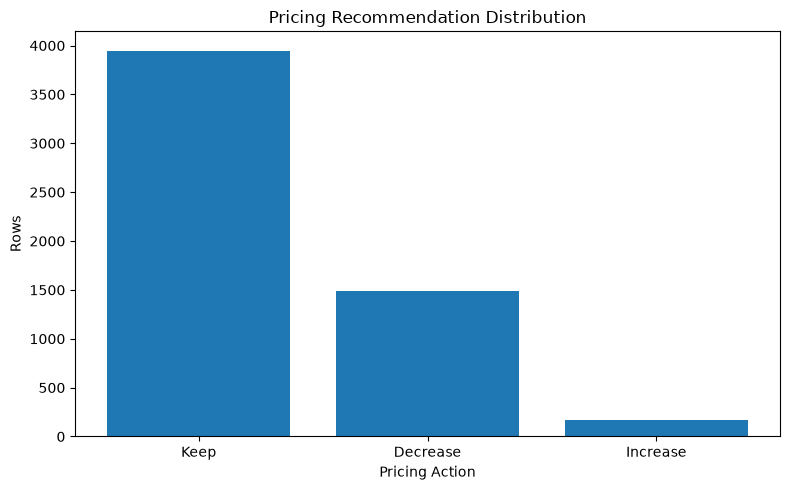

In [16]:
fig, ax = plt.subplots(figsize=(8, 5))

ax.bar(
    pricing_action_summary[
        "pricing_action"
    ],
    pricing_action_summary[
        "rows"
    ],
)

ax.set_title(
    "Pricing Recommendation Distribution"
)
ax.set_xlabel("Pricing Action")
ax.set_ylabel("Rows")

plt.tight_layout()
plt.show()

## 17. Aggregate Expected Revenue Impact

Sum current and recommended expected revenue across all pricing-eligible test observations.

In [17]:
aggregate_current_revenue = (
    pricing_results[
        "current_expected_revenue"
    ].sum()
)

aggregate_recommended_revenue = (
    pricing_results[
        "expected_revenue"
    ].sum()
)

aggregate_revenue_lift = (
    aggregate_recommended_revenue
    - aggregate_current_revenue
)

aggregate_revenue_lift_pct = (
    aggregate_revenue_lift
    / aggregate_current_revenue
)

print(
    "Current expected revenue:",
    f"${aggregate_current_revenue:,.2f}",
)

print(
    "Recommended expected revenue:",
    f"${aggregate_recommended_revenue:,.2f}",
)

print(
    "Expected revenue lift:",
    f"${aggregate_revenue_lift:,.2f}",
)

print(
    "Expected revenue lift percent:",
    f"{aggregate_revenue_lift_pct:.2%}",
)

Current expected revenue: $22,081.75
Recommended expected revenue: $23,200.21
Expected revenue lift: $1,118.46
Expected revenue lift percent: 5.07%


## 18. Revenue Lift by Product

Identify products with the largest projected revenue opportunities.

In [18]:
product_pricing_summary = (
    pricing_results
    .groupby(
        "item_id",
        as_index=False,
    )
    .agg(
        current_expected_revenue=(
            "current_expected_revenue",
            "sum",
        ),
        recommended_expected_revenue=(
            "expected_revenue",
            "sum",
        ),
        average_current_price=(
            "sell_price",
            "mean",
        ),
        average_recommended_price=(
            "recommended_price",
            "mean",
        ),
        average_elasticity=(
            "usable_elasticity",
            "mean",
        ),
    )
)

product_pricing_summary[
    "expected_revenue_lift"
] = (
    product_pricing_summary[
        "recommended_expected_revenue"
    ]
    - product_pricing_summary[
        "current_expected_revenue"
    ]
)

product_pricing_summary[
    "expected_revenue_lift_pct"
] = (
    product_pricing_summary[
        "expected_revenue_lift"
    ]
    / product_pricing_summary[
        "current_expected_revenue"
    ].replace(0, np.nan)
)

product_pricing_summary = (
    product_pricing_summary
    .sort_values(
        "expected_revenue_lift",
        ascending=False,
    )
)

product_pricing_summary.head(20)

,item_id,current_expected_revenue,recommended_expected_revenue,average_current_price,average_recommended_price,average_elasticity,expected_revenue_lift,expected_revenue_lift_pct
183,FOODS_1_187,387.348466,478.207983,9.942857,8.948571,-3.000000,90.859517,0.234568
41,FOODS_1_043,373.949367,461.665885,1.960000,1.764000,-3.000000,87.716518,0.234568
53,FOODS_1_055,309.209722,381.740397,4.380000,3.942000,-3.000000,72.530676,0.234568
107,FOODS_1_110,289.253586,357.103192,1.960000,1.764000,-3.000000,67.849607,0.234568
3,FOODS_1_004,185.626376,229.168365,1.960000,1.764000,-3.000000,43.541989,0.234568
150,FOODS_1_153,150.476236,185.773131,1.980000,1.782000,-3.000000,35.296895,0.234568
197,FOODS_1_201,149.401548,184.446356,2.240000,2.016000,-3.000000,35.044808,0.234568
34,FOODS_1_036,130.886464,161.588227,1.780000,1.602000,-3.000000,30.701763,0.234568
168,FOODS_1_172,128.408764,158.529339,1.980000,1.782000,-3.000000,30.120574,0.234568
147,FOODS_1_150,127.289765,157.147858,5.280000,4.752000,-3.000000,29.858093,0.234568


## 19. Elasticity Confidence Summary

Not every item has enough clean historical price changes to support an observed elasticity assumption.

The source label was assigned earlier using the same validity rule that determined the usable elasticity:

- `Observed` — enough observations **and** a negative median elasticity
- `Fallback` — insufficient or unsuitable historical evidence, so the default elasticity is used

This keeps the confidence label consistent with the actual elasticity used by the pricing engine.

In [19]:
elasticity_source_summary = (
    pricing_results[
        "elasticity_source"
    ]
    .value_counts()
    .rename_axis(
        "elasticity_source"
    )
    .reset_index(
        name="rows"
    )
)

elasticity_source_summary["share"] = (
    elasticity_source_summary["rows"]
    / elasticity_source_summary["rows"].sum()
)

elasticity_source_summary

,elasticity_source,rows,share
0,Fallback,3948,0.705
1,Observed,1652,0.295


## 20. Conservative Recommendation Filter and Pricing Validation

A pricing engine should not blindly act on every modeled improvement.

A recommendation is considered actionable only when:

- expected revenue lift is at least **1%**
- baseline predicted demand is positive
- current price is valid

This section also validates that:

- every recommendation stays inside the ±10% guardrail
- recommended prices are positive
- the recommendation engine does not select a materially worse expected-revenue scenario than the current-price scenario

In [20]:
MIN_REVENUE_LIFT_PCT = 0.01

pricing_results[
    "recommendation_actionable"
] = (
    pricing_results[
        "expected_revenue_lift_pct"
    ]
    >= MIN_REVENUE_LIFT_PCT
) & (
    pricing_results[
        "prediction"
    ] > 0
) & (
    pricing_results[
        "sell_price"
    ] > 0
)

# Validate price guardrails.
if (
    pricing_results[
        "recommended_change_pct"
    ].abs()
    > 0.10 + 1e-12
).any():
    raise ValueError(
        "A recommended price exceeds the ±10% pricing guardrail."
    )

if (
    pricing_results[
        "recommended_price"
    ]
    <= 0
).any():
    raise ValueError(
        "A non-positive recommended price was found."
    )

# Allow only a tiny numerical tolerance below the current scenario.
revenue_tolerance = np.maximum(
    pricing_results[
        "current_expected_revenue"
    ].abs()
    * REVENUE_TOLERANCE_PCT,
    1e-9,
)

materially_worse = (
    pricing_results[
        "expected_revenue"
    ]
    <
    pricing_results[
        "current_expected_revenue"
    ]
    - revenue_tolerance
)

if materially_worse.any():
    raise ValueError(
        "A recommendation is materially worse than the current-price scenario."
    )

print(
    "Actionable recommendations:",
    f"{pricing_results['recommendation_actionable'].sum():,}",
)

print(
    "Share actionable:",
    f"{pricing_results['recommendation_actionable'].mean():.2%}",
)

print("PASS: price guardrails")
print("PASS: positive recommended prices")
print("PASS: no materially worse revenue recommendations")

Actionable recommendations: 1,624
Share actionable: 29.00%
PASS: price guardrails
PASS: positive recommended prices
PASS: no materially worse revenue recommendations


## 21. Inspect Top Actionable Recommendations

In [21]:
top_recommendations = (
    pricing_results.loc[
        pricing_results[
            "recommendation_actionable"
        ]
    ]
    .sort_values(
        "expected_revenue_lift",
        ascending=False,
    )
    [
        [
            "date",
            "item_id",
            "store_id",
            "sell_price",
            "recommended_price",
            "recommended_change_pct",
            "prediction",
            "expected_demand",
            "usable_elasticity",
            "elasticity_source",
            "current_expected_revenue",
            "expected_revenue",
            "expected_revenue_lift",
            "expected_revenue_lift_pct",
        ]
    ]
)

top_recommendations.head(25)

,date,item_id,store_id,sell_price,recommended_price,recommended_change_pct,prediction,expected_demand,usable_elasticity,elasticity_source,current_expected_revenue,expected_revenue,expected_revenue_lift,expected_revenue_lift_pct
2453,2016-05-07,FOODS_1_055,CA_1,4.38,3.942,-0.1,5.595471,7.675543,-3.0,Observed,24.508161,30.256989,5.748828,0.234568
1183,2016-04-30,FOODS_1_187,CA_1,9.94,8.946,-0.1,2.384811,3.271346,-3.0,Observed,23.705023,29.265461,5.560438,0.234568
1041,2016-04-30,FOODS_1_043,CA_1,1.96,1.764,-0.1,12.058599,16.541287,-3.0,Observed,23.634853,29.178831,5.543978,0.234568
2241,2016-05-06,FOODS_1_043,CA_1,1.96,1.764,-0.1,11.334650,15.548217,-3.0,Observed,22.215915,27.427055,5.211140,0.234568
3983,2016-05-14,FOODS_1_187,CA_1,9.94,8.946,-0.1,2.176506,2.985605,-3.0,Observed,21.634472,26.709225,5.074753,0.234568
4183,2016-05-15,FOODS_1_187,CA_1,9.94,8.946,-0.1,2.131520,2.923896,-3.0,Observed,21.187310,26.157172,4.969863,0.234568
2641,2016-05-08,FOODS_1_043,CA_1,1.96,1.764,-0.1,10.753136,14.750529,-3.0,Observed,21.076146,26.019933,4.943787,0.234568
3841,2016-05-14,FOODS_1_043,CA_1,1.96,1.764,-0.1,10.727155,14.714891,-3.0,Observed,21.025224,25.957067,4.931843,0.234568
5307,2016-05-21,FOODS_1_110,CA_1,1.96,1.764,-0.1,9.844465,13.504068,-3.0,Observed,19.295152,23.821176,4.526023,0.234568
4453,2016-05-17,FOODS_1_055,CA_1,4.38,3.942,-0.1,4.398875,6.034122,-3.0,Observed,19.267072,23.786508,4.519437,0.234568


## 22. Save Pricing Recommendations

In [22]:
pricing_results.to_csv(
    PRICING_RECOMMENDATIONS_FILE,
    index=False,
)

print(
    "Saved pricing recommendations:",
    PRICING_RECOMMENDATIONS_FILE,
)

print(
    "Rows:",
    f"{len(pricing_results):,}",
)

Saved pricing recommendations: ..\outputs\pricing\pricing_recommendations.csv
Rows: 5,600


## 23. Dynamic Pricing Findings

### Elasticity

- **1,652 pricing rows** used an observed item-level elasticity.
- **3,948 pricing rows** used the fallback elasticity.
- About **29.5%** of pricing rows therefore rely on observed item-specific price-response evidence, while about **70.5%** rely on the fallback assumption.
- Historical elasticity estimates remain noisy and observational, so they should not be interpreted as causal estimates of how customers will respond to a future price change.

### Pricing Actions

- **70.5%** of pricing rows recommend keeping the current price.
- **26.5%** recommend decreasing the price.
- **3.0%** recommend increasing the price.
- **1,624 rows**, or about **29.0%**, pass the actionable-recommendation threshold.
- The corrected tie-handling materially increased `Keep` recommendations by choosing the current price whenever several candidate prices produce effectively equal expected revenue.

### Expected Revenue

- Current expected revenue: **$22,081.75**
- Recommended expected revenue: **$23,200.21**
- Simulated expected revenue lift: **$1,118.46**
- Simulated expected revenue lift percentage: **5.07%**

These values are **scenario-model outputs**, not realized business results.

### Business Interpretation

- Most pricing observations remain at the current price, which is preferable to making unnecessary price changes when the modeled revenue difference is negligible.
- The largest simulated pricing opportunities are concentrated among rows where the assumed price-response curve produces a meaningful expected-revenue improvement.
- A large share of the recommendations still depends on fallback elasticity rather than strong item-specific evidence.
- Production guardrails should continue to include:
  - constrained price changes
  - positive-price checks
  - minimum expected-revenue-lift thresholds
  - confidence labels for observed vs. fallback elasticity
  - protection against recommendations that are materially worse than the current-price scenario

### Final Pricing Decision

- The development pricing engine is **useful enough to move into application development**.
- The pricing results should be described as **simulated pricing scenarios**, not causal proof that the recommended prices will produce the estimated revenue gains.
- The most important additional data for a stronger production system would include:
  - product cost and margin data
  - inventory levels and stockout information
  - promotion history
  - competitor pricing
  - stronger price-experiment or causal-response data
- Real deployment should validate pricing behavior through controlled experiments or stronger causal-inference methods.


## 24. Important Pricing Limitations

This notebook should be interpreted carefully.

### 1. Elasticity is observational

Historical price and demand changes can be influenced by:

- promotions
- seasonality
- inventory availability
- holidays
- competitor activity
- product lifecycle
- unobserved business decisions

Therefore this notebook does **not** claim causal price elasticity.

### 2. Many recommendations may use a fallback assumption

When an item lacks enough suitable historical price changes, the engine uses the fallback elasticity.

Those recommendations are scenario analyses under an assumption, not item-specific learned price response.

### 3. Revenue is not profit

Without product-level cost and margin data, the engine optimizes expected **revenue**, not contribution margin or profit.

A production pricing system should include:

- unit cost
- margin floor
- inventory holding cost
- markdown cost
- stockout cost

### 4. Forecasting remains daily-updated

The underlying demand model is currently evaluated as a daily-updated forecasting workflow.

A strict future 28-day pricing system will require recursive or horizon-safe demand forecasting.

### 5. Candidate prices are constrained

Recommendations are limited to ±10% around current price for development safety.

When several candidate prices produce effectively equal expected revenue, the engine deliberately prefers the price closest to the current price.

### 6. Simulated revenue lift is not realized revenue lift

Any reported revenue increase is calculated from:

- model-predicted baseline demand
- an assumed or observational elasticity
- a constant-elasticity response curve

It should be described as **simulated expected revenue lift**, not as a proven business result.

### 7. Real deployment requires experimentation

The strongest way to validate price response is through controlled experiments, randomized price tests, or stronger causal-inference designs.

## 25. Notebook Phase Complete

The corrected pricing logic has been rerun, the final pricing outputs have been reviewed, and the findings above have been updated with the actual results.

The main six-notebook analysis phase is now complete:

1. `01_data_profiling.ipynb`
2. `02_exploratory_data_analysis.ipynb`
3. `03_feature_engineering.ipynb`
4. `04_modeling.ipynb`
5. `05_model_evaluation.ipynb`
6. `06_dynamic_pricing.ipynb`

The project now moves from experimentation into **production engineering**.

### Next Project Steps

1. Move feature-engineering logic into reusable Python modules.
2. Build a strict production forecasting workflow for future horizons.
3. Move model inference into a forecasting service.
4. Move corrected pricing logic into a reusable pricing module.
5. Add automated unit tests and data-quality tests.
6. Create FastAPI endpoints such as:
   - `/forecast`
   - `/recommend-price`
7. Build a Streamlit dashboard.
8. Connect the workflow to Airflow.
9. Integrate the services into Docker.
10. Finalize the README, architecture diagram, screenshots, metrics, and business limitations.
11. Deploy the application.

The production pricing service must preserve the notebook's guardrails and clearly distinguish **forecast outputs**, **scenario pricing outputs**, and **causal business claims**.
